In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv('ecommerce_dataset.csv')


In [3]:
df

,Customer_ID,Age,Gender,Annual_Income_k$,Spending_Score,Membership_Years,Device_Used,City_Tier,Purchase_Made
0,1,25.0,Female,500,35,1.0,Desktop,Tier 3,1
1,2,65.0,Female,76,62,1.0,Tablet,Tier 1,1
2,3,45.0,Male,91,1,2.0,Mobile,Tier 1,1
3,4,35.0,Male,26,25,1.0,Desktop,Tier 3,0
4,5,18.0,Male,500,45,5.0,Tablet,Tier 3,1
...,...,...,...,...,...,...,...,...,...
1495,1496,45.0,Other,118,27,1.0,Desktop,Tier 1,0
1496,1497,35.0,Male,38,6,4.0,Mobile,Tier 2,1
1497,1498,35.0,Male,500,17,2.0,Desktop,Tier 3,1
1498,1499,25.0,Male,500,36,3.0,Tablet,Tier 3,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       1500 non-null   int64  
 1   Age               1339 non-null   float64
 2   Gender            1355 non-null   str    
 3   Annual_Income_k$  1500 non-null   int64  
 4   Spending_Score    1500 non-null   int64  
 5   Membership_Years  1255 non-null   float64
 6   Device_Used       1500 non-null   str    
 7   City_Tier         1500 non-null   str    
 8   Purchase_Made     1500 non-null   int64  
dtypes: float64(2), int64(4), str(3)
memory usage: 105.6 KB


In [5]:
df.describe()

,Customer_ID,Age,Annual_Income_k$,Spending_Score,Membership_Years,Purchase_Made
count,1500.000000,1339.000000,1500.000000,1500.000000,1255.000000,1500.000000
mean,750.500000,37.362957,141.717333,50.562000,2.967331,0.702000
std,433.157015,15.250906,156.061063,28.614495,1.401088,0.457532
min,1.000000,18.000000,20.000000,1.000000,1.000000,0.000000
25%,375.750000,25.000000,54.000000,25.000000,2.000000,0.000000
50%,750.500000,35.000000,86.500000,51.500000,3.000000,1.000000
75%,1125.250000,45.000000,118.000000,76.000000,4.000000,1.000000
max,1500.000000,65.000000,500.000000,99.000000,5.000000,1.000000


In [6]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Annual_Income_k$', 'Spending_Score',
       'Membership_Years', 'Device_Used', 'City_Tier', 'Purchase_Made'],
      dtype='str')

In [7]:
df.isnull().sum()

Customer_ID           0
Age                 161
Gender              145
Annual_Income_k$      0
Spending_Score        0
Membership_Years    245
Device_Used           0
City_Tier             0
Purchase_Made         0
dtype: int64

# Exploratory data analysis (EDA)

In [8]:
df.select_dtypes(include="number").columns

Index(['Customer_ID', 'Age', 'Annual_Income_k$', 'Spending_Score',
       'Membership_Years', 'Purchase_Made'],
      dtype='str')

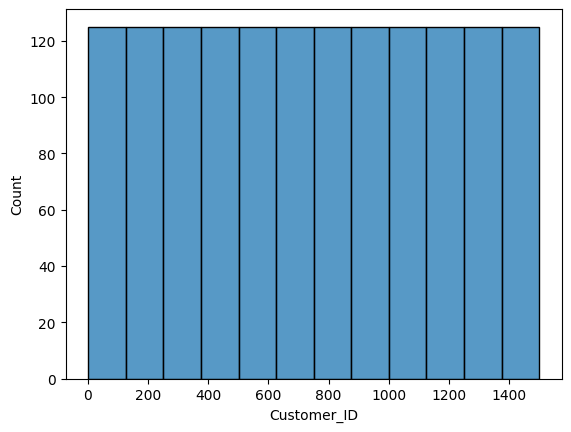

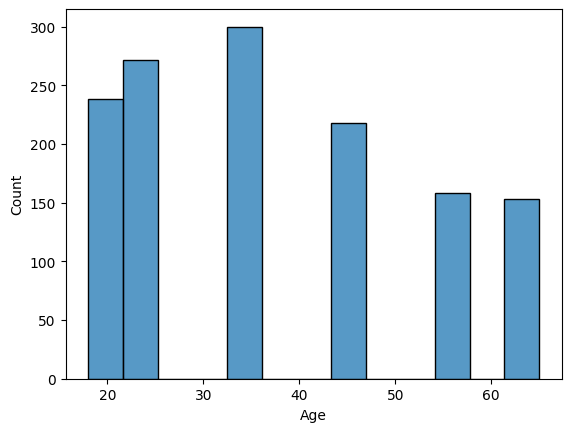

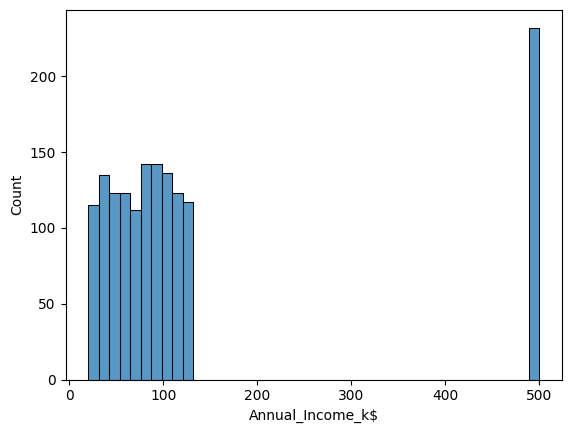

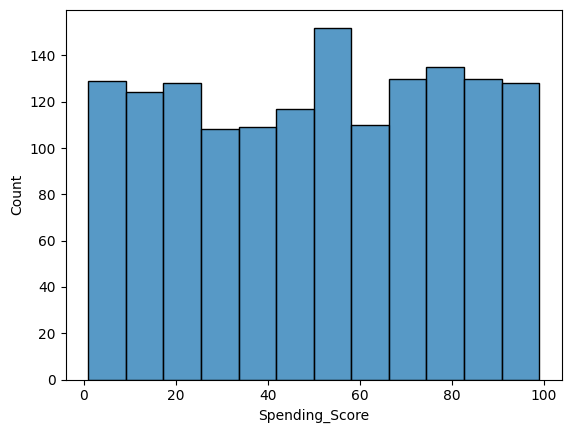

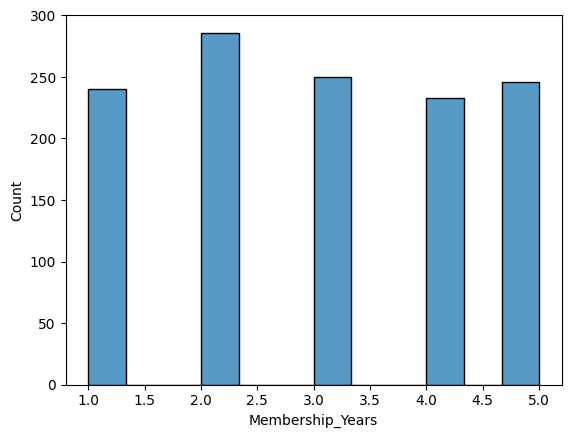

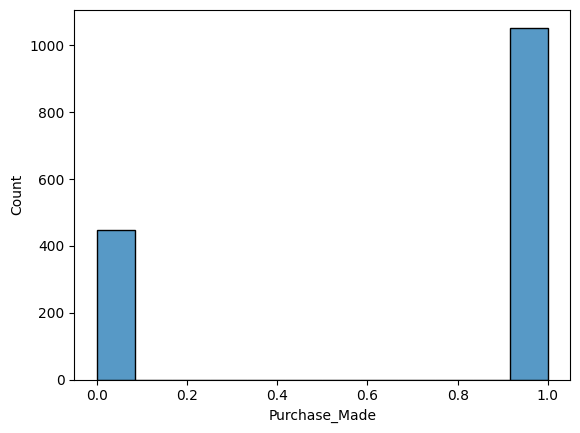

In [9]:
#Histrogram 
for i in df.select_dtypes(include='number').columns:
    sns.histplot(data=df,x=i)
    plt.show()

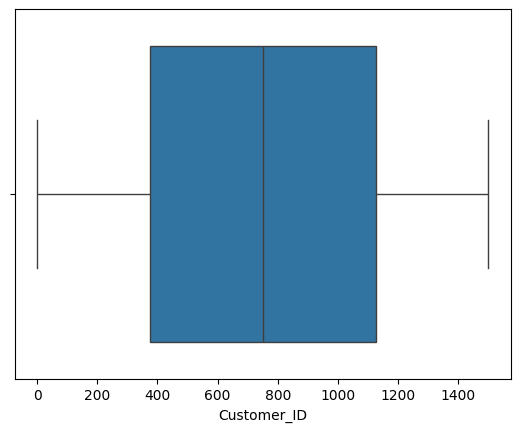

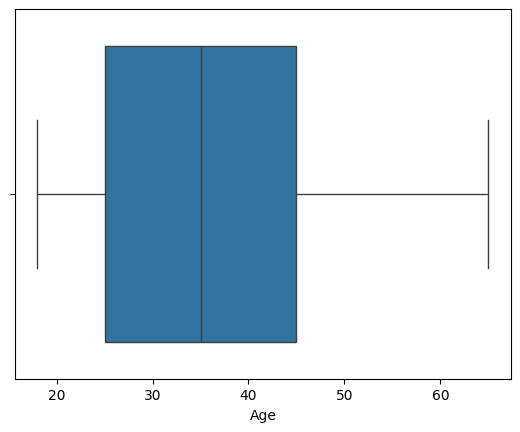

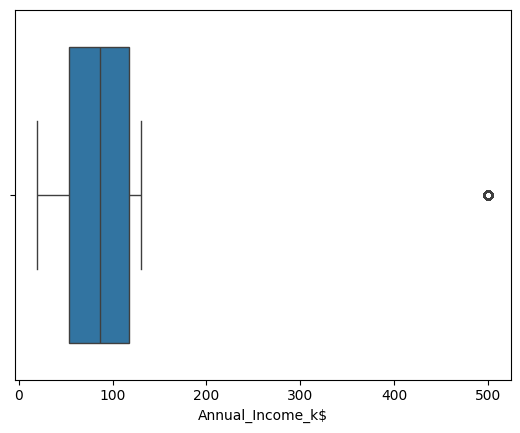

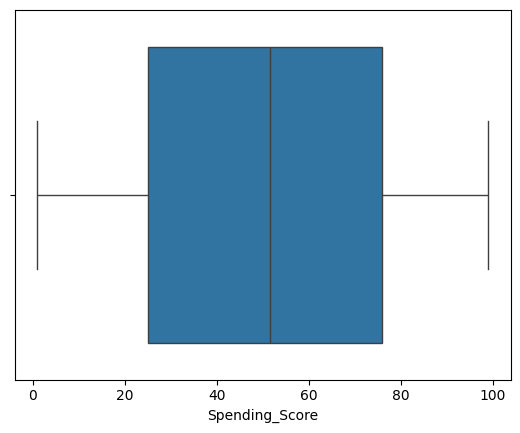

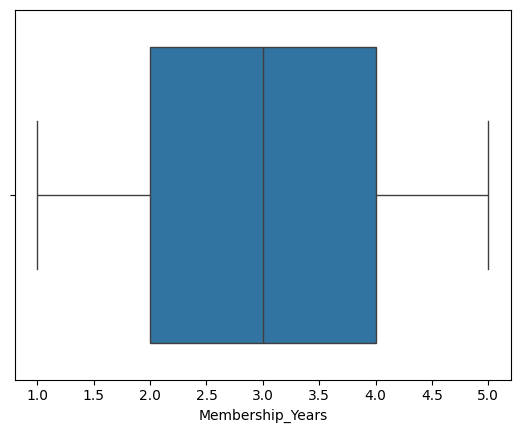

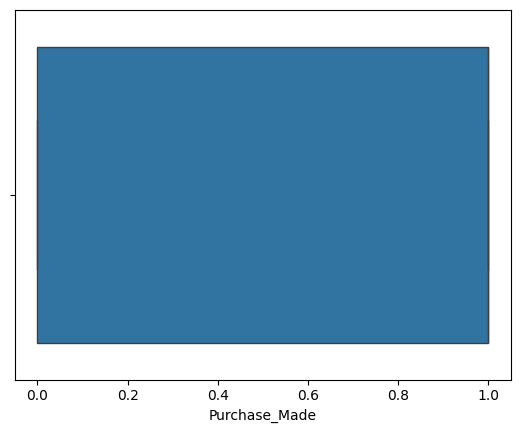

In [10]:
#Box Plot 
for i in df.select_dtypes(include='number').columns:
    sns.boxplot(data=df,x=i)
    plt.show()

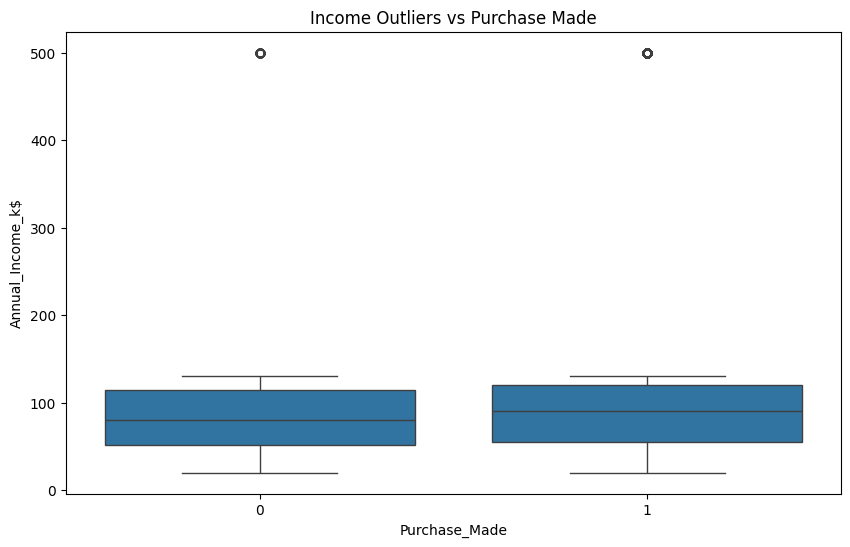

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Purchase_Made', y='Annual_Income_k$', data=df)
plt.title('Income Outliers vs Purchase Made')
plt.show()

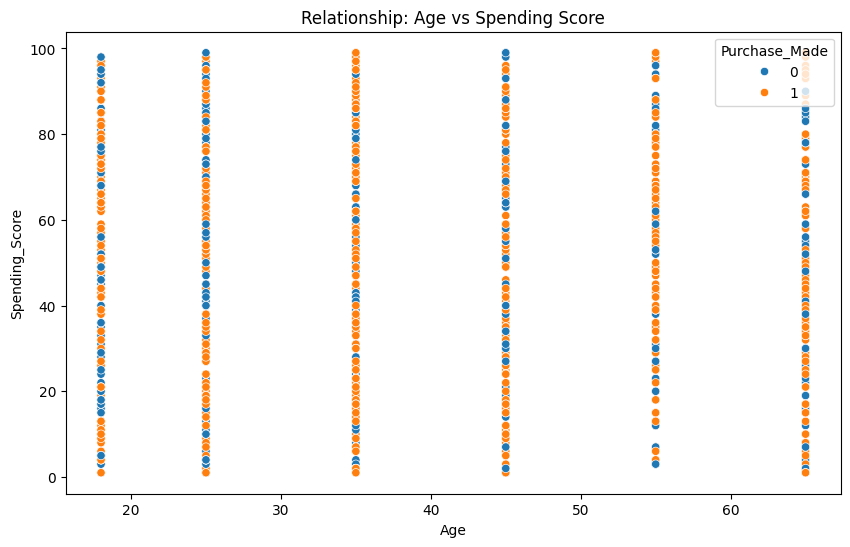

In [12]:
# Scatterplot
# Plot 1: Age vs Spending Score
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Spending_Score', hue='Purchase_Made', )
plt.title('Relationship: Age vs Spending Score')
plt.show()

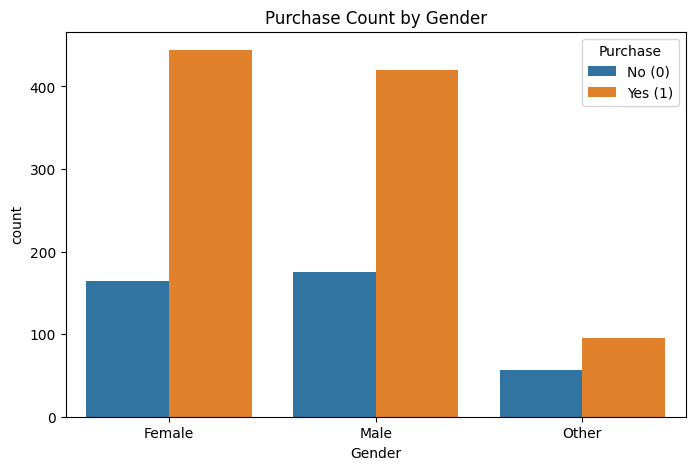

In [13]:
# Count Plot 
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Gender', hue='Purchase_Made',)
plt.title('Purchase Count by Gender')
plt.legend(title='Purchase', labels=['No (0)', 'Yes (1)'])
plt.show()

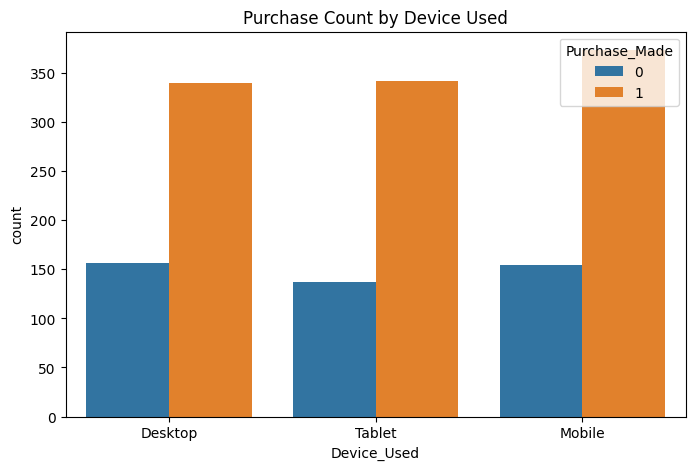

In [14]:
# 2. Device Used vs Purchase 
plt.figure(figsize=(8, 5))
sns.countplot(x='Device_Used', hue='Purchase_Made', data=df)
plt.title('Purchase Count by Device Used')
plt.show()

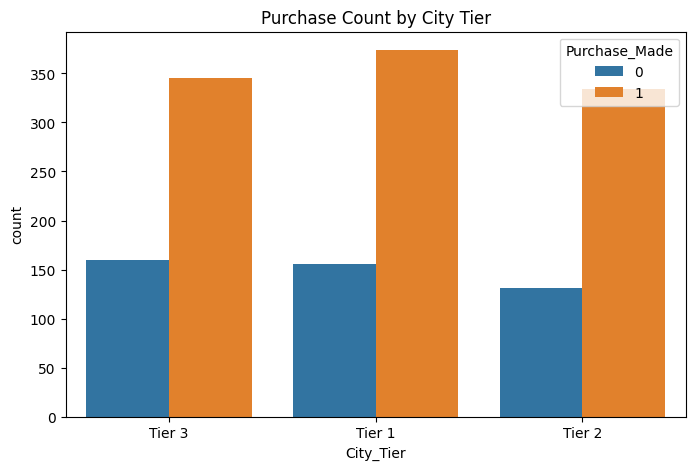

In [15]:
#3. City Tier vs Purchase 
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='City_Tier', hue='Purchase_Made')
plt.title('Purchase Count by City Tier')
plt.show()

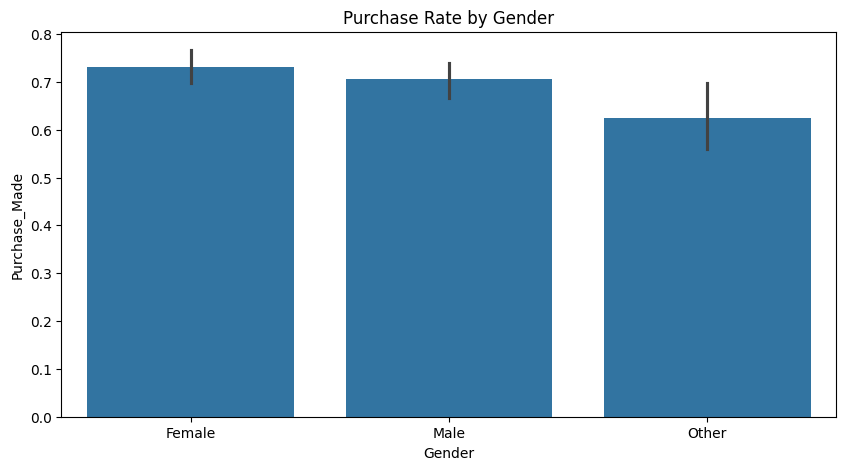

In [16]:
# 4. Bar Plot (Categorical vs Target)

plt.figure(figsize=(10, 5))
sns.barplot(x='Gender', y='Purchase_Made', data=df)
plt.title('Purchase Rate by Gender')
plt.show()

<Axes: >

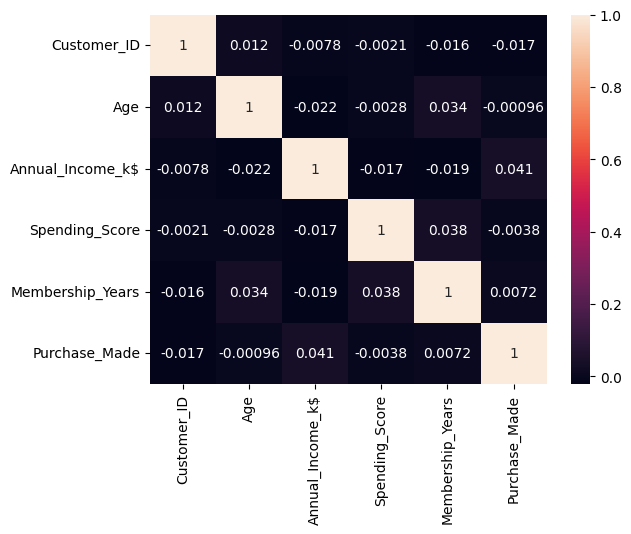

In [17]:
# Heatmap
s = df.select_dtypes(include="number").corr()
sns.heatmap(s, annot=True)

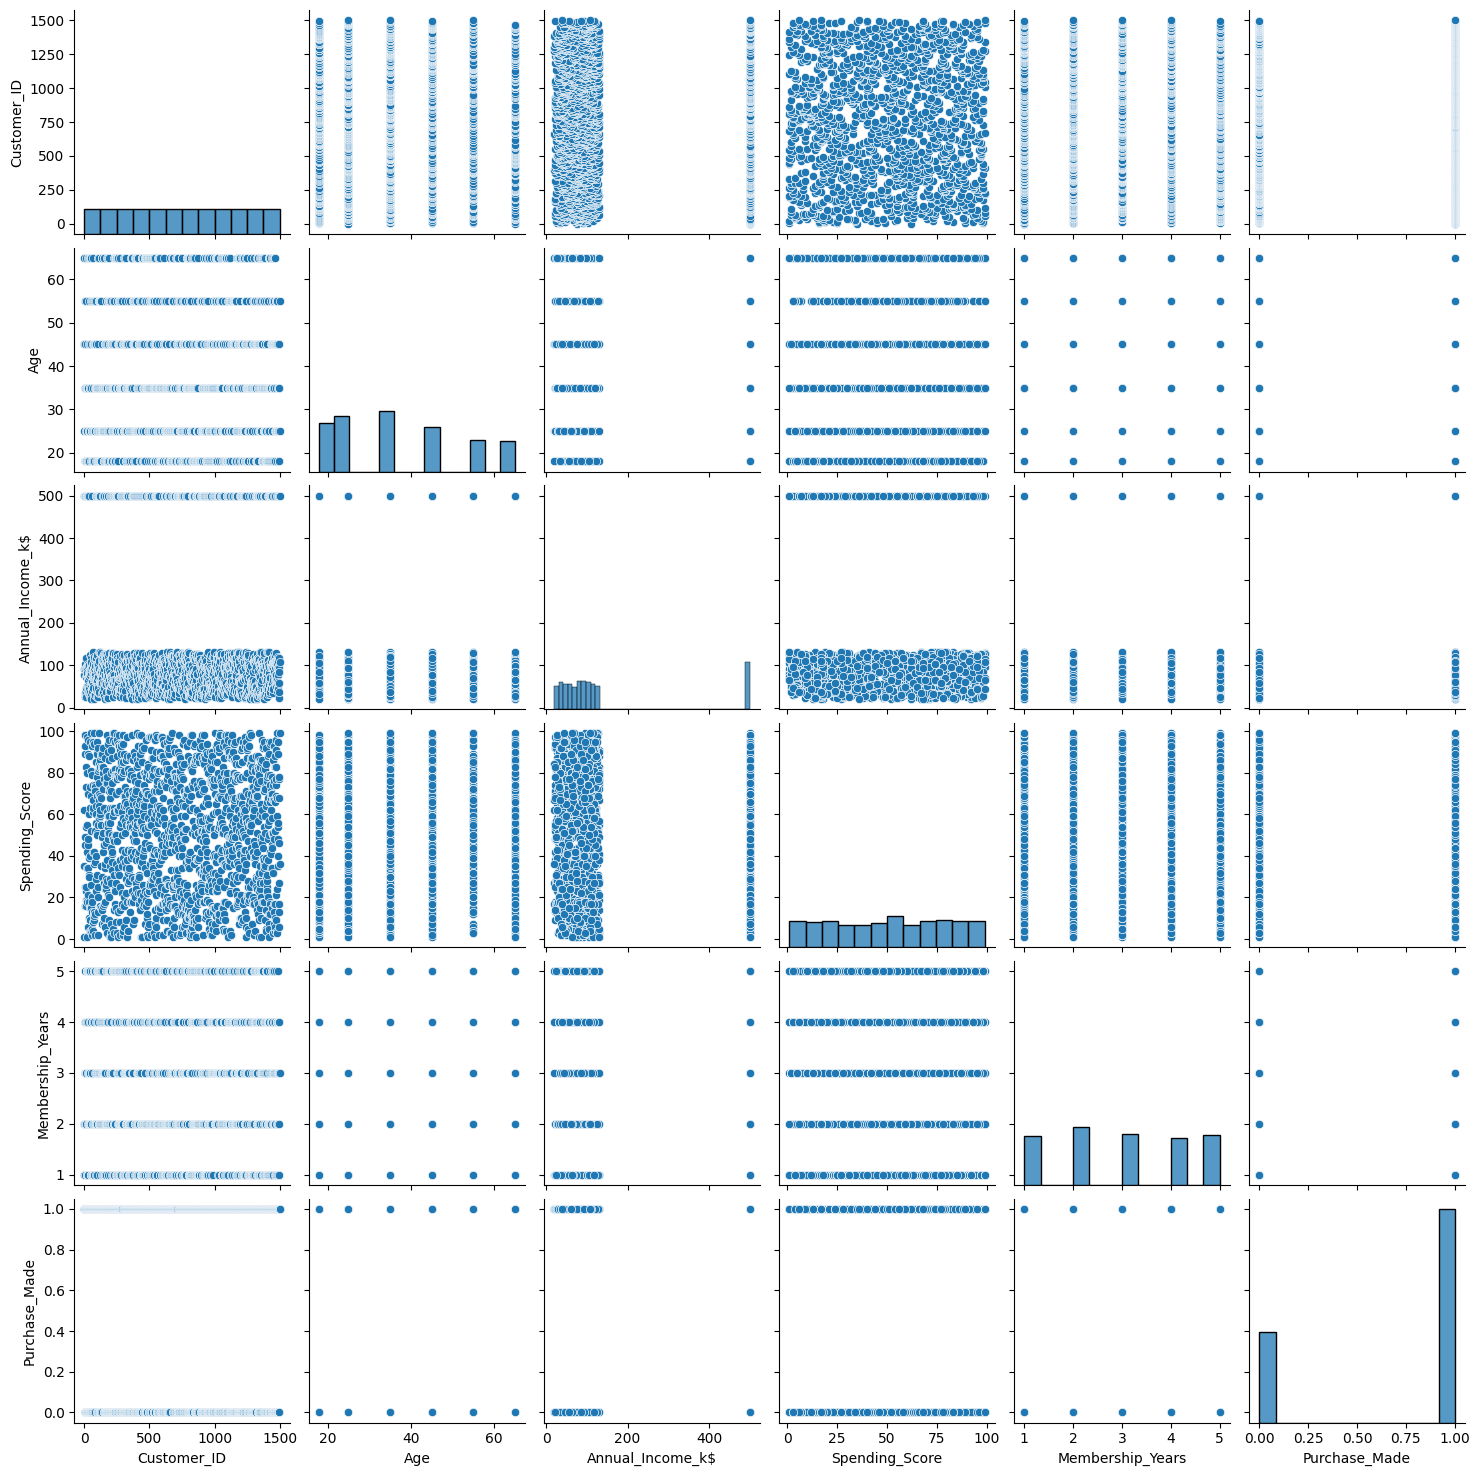

In [18]:
#Pair Plot
sns.pairplot(data=df)

In [19]:
# Handling missing values

In [20]:
df.select_dtypes(include="number").columns

Index(['Customer_ID', 'Age', 'Annual_Income_k$', 'Spending_Score',
       'Membership_Years', 'Purchase_Made'],
      dtype='str')

In [21]:
df.isnull().sum()

Customer_ID           0
Age                 161
Gender              145
Annual_Income_k$      0
Spending_Score        0
Membership_Years    245
Device_Used           0
City_Tier             0
Purchase_Made         0
dtype: int64

In [22]:
# Median
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Membership_Years"] = df["Membership_Years"].fillna(df["Membership_Years"].median())

In [23]:
df.isnull().sum()

Customer_ID           0
Age                   0
Gender              145
Annual_Income_k$      0
Spending_Score        0
Membership_Years      0
Device_Used           0
City_Tier             0
Purchase_Made         0
dtype: int64

In [24]:
df

,Customer_ID,Age,Gender,Annual_Income_k$,Spending_Score,Membership_Years,Device_Used,City_Tier,Purchase_Made
0,1,25.0,Female,500,35,1.0,Desktop,Tier 3,1
1,2,65.0,Female,76,62,1.0,Tablet,Tier 1,1
2,3,45.0,Male,91,1,2.0,Mobile,Tier 1,1
3,4,35.0,Male,26,25,1.0,Desktop,Tier 3,0
4,5,18.0,Male,500,45,5.0,Tablet,Tier 3,1
...,...,...,...,...,...,...,...,...,...
1495,1496,45.0,Other,118,27,1.0,Desktop,Tier 1,0
1496,1497,35.0,Male,38,6,4.0,Mobile,Tier 2,1
1497,1498,35.0,Male,500,17,2.0,Desktop,Tier 3,1
1498,1499,25.0,Male,500,36,3.0,Tablet,Tier 3,1


In [25]:
#Encoding
#Identify categorical columns in the dataset
categorical_columns = df.select_dtypes(include=['object']).columns
print(categorical_columns)

Index(['Gender', 'Device_Used', 'City_Tier'], dtype='str')


C:\Users\Ali\AppData\Local\Temp\ipykernel_14596\460377983.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


In [26]:
df.Gender.unique()

<StringArray>
['Female', 'Male', 'Other', nan]
Length: 4, dtype: str

In [27]:
df.Device_Used.unique()

<StringArray>
['Desktop', 'Tablet', 'Mobile']
Length: 3, dtype: str

In [28]:
df.City_Tier.unique()

<StringArray>
['Tier 3', 'Tier 1', 'Tier 2']
Length: 3, dtype: str

In [29]:
# One Hot Encording
df = pd.get_dummies (df, columns=['Gender'], dtype= 'int64')
df = pd.get_dummies (df, columns=['Device_Used'], dtype= 'int64')
df = pd.get_dummies (df, columns=['City_Tier'], dtype= 'int64')


In [30]:
df

,Customer_ID,Age,Annual_Income_k$,Spending_Score,Membership_Years,Purchase_Made,Gender_Female,Gender_Male,Gender_Other,Device_Used_Desktop,Device_Used_Mobile,Device_Used_Tablet,City_Tier_Tier 1,City_Tier_Tier 2,City_Tier_Tier 3
0,1,25.0,500,35,1.0,1,1,0,0,1,0,0,0,0,1
1,2,65.0,76,62,1.0,1,1,0,0,0,0,1,1,0,0
2,3,45.0,91,1,2.0,1,0,1,0,0,1,0,1,0,0
3,4,35.0,26,25,1.0,0,0,1,0,1,0,0,0,0,1
4,5,18.0,500,45,5.0,1,0,1,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,1496,45.0,118,27,1.0,0,0,0,1,1,0,0,1,0,0
1496,1497,35.0,38,6,4.0,1,0,1,0,0,1,0,0,1,0
1497,1498,35.0,500,17,2.0,1,0,1,0,1,0,0,0,0,1
1498,1499,25.0,500,36,3.0,1,0,1,0,0,0,1,0,0,1


In [31]:

#Feature Scaling
#Identifying columns that may require feature scaling
numerical_features = df.select_dtypes(include=['int64','float64']).columns
numerical_features

Index(['Customer_ID', 'Age', 'Annual_Income_k$', 'Spending_Score',
       'Membership_Years', 'Purchase_Made', 'Gender_Female', 'Gender_Male',
       'Gender_Other', 'Device_Used_Desktop', 'Device_Used_Mobile',
       'Device_Used_Tablet', 'City_Tier_Tier 1', 'City_Tier_Tier 2',
       'City_Tier_Tier 3'],
      dtype='str')

In [32]:
from sklearn.preprocessing import StandardScaler

In [33]:
scaler = StandardScaler()
df[[ 'Age', 'Annual_Income_k$', 'Spending_Score', 'Membership_Years']]=scaler.fit_transform(df[['Age', 'Annual_Income_k$', 'Spending_Score', 'Membership_Years']])

In [34]:
df

,Customer_ID,Age,Annual_Income_k$,Spending_Score,Membership_Years,Purchase_Made,Gender_Female,Gender_Male,Gender_Other,Device_Used_Desktop,Device_Used_Mobile,Device_Used_Tablet,City_Tier_Tier 1,City_Tier_Tier 2,City_Tier_Tier 3
0,1,-0.839620,2.296551,-0.544032,-1.539806,1,1,0,0,1,0,0,0,0,1
1,2,1.933845,-0.421241,0.399861,-1.539806,1,1,0,0,0,0,1,1,0,0
2,3,0.547112,-0.325092,-1.732637,-0.759235,1,0,1,0,0,1,0,1,0,0
3,4,-0.146254,-0.741735,-0.893621,-1.539806,0,0,1,0,1,0,0,0,0,1
4,5,-1.324977,2.296551,-0.194442,1.582477,1,0,1,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,1496,0.547112,-0.152025,-0.823703,-1.539806,0,0,0,1,1,0,0,1,0,0
1496,1497,-0.146254,-0.664816,-1.557842,0.801906,1,0,1,0,0,1,0,0,1,0
1497,1498,-0.146254,2.296551,-1.173293,-0.759235,1,0,1,0,1,0,0,0,0,1
1498,1499,-0.839620,2.296551,-0.509073,0.021336,1,0,1,0,0,0,1,0,0,1


In [35]:
X = df.drop(['Purchase_Made', 'Customer_ID'], axis=1)
X

,Age,Annual_Income_k$,Spending_Score,Membership_Years,Gender_Female,Gender_Male,Gender_Other,Device_Used_Desktop,Device_Used_Mobile,Device_Used_Tablet,City_Tier_Tier 1,City_Tier_Tier 2,City_Tier_Tier 3
0,-0.839620,2.296551,-0.544032,-1.539806,1,0,0,1,0,0,0,0,1
1,1.933845,-0.421241,0.399861,-1.539806,1,0,0,0,0,1,1,0,0
2,0.547112,-0.325092,-1.732637,-0.759235,0,1,0,0,1,0,1,0,0
3,-0.146254,-0.741735,-0.893621,-1.539806,0,1,0,1,0,0,0,0,1
4,-1.324977,2.296551,-0.194442,1.582477,0,1,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,0.547112,-0.152025,-0.823703,-1.539806,0,0,1,1,0,0,1,0,0
1496,-0.146254,-0.664816,-1.557842,0.801906,0,1,0,0,1,0,0,1,0
1497,-0.146254,2.296551,-1.173293,-0.759235,0,1,0,1,0,0,0,0,1
1498,-0.839620,2.296551,-0.509073,0.021336,0,1,0,0,0,1,0,0,1


In [36]:
y = df['Purchase_Made']
y

0       1
1       1
2       1
3       0
4       1
       ..
1495    0
1496    1
1497    1
1498    1
1499    1
Name: Purchase_Made, Length: 1500, dtype: int64

In [37]:
# Splitting
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [51]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix


scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model_svc = SVC(kernel='rbf')
model_svc.fit(x_train_scaled, y_train)

prediction_svc = model_svc.predict(x_test_scaled)


In [52]:
model_svc = SVC()
model_svc.fit(x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [53]:
prediction_svc = model_svc.predict(x_test)
prediction_svc

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [54]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score

In [55]:
accuracy_score(y_test,prediction_svc)

0.7022222222222222

In [56]:
confusion_matrix(y_test,prediction_svc)

array([[  0, 134],
       [  0, 316]])

In [57]:
precision_score(y_test,prediction_svc)

0.7022222222222222

In [58]:
recall_score(y_test,prediction_svc)

1.0

In [59]:
from sklearn.metrics import classification_report

In [60]:
print(classification_report(y_test,prediction_svc))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       134
           1       0.70      1.00      0.83       316

    accuracy                           0.70       450
   macro avg       0.35      0.50      0.41       450
weighted avg       0.49      0.70      0.58       450



C:\Users\Ali\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Ali\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Ali\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [ ]:
print("Confusion Matrix:\n", confusion_matrix(y_test, prediction_svc))
print("\nClassification Report:\n", classification_report(y_test, prediction_svc))

In [ ]:
# Random Forest

In [48]:
from sklearn.ensemble import RandomForestClassifier

In [49]:
model_rf = RandomForestClassifier(n_estimators=100, max_depth=5)
model_rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [62]:
prediction_dt = model_rf.predict(x_test)
prediction_dt

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [68]:
mse = mean_squared_error(y_test, prediction_rf)
print(f"MSE = {mse}")

NameError: name 'mean_squared_error' is not defined

In [67]:
r2 = r2_score(y_test, prediction_rf)
print(f"R Square = {r2}")

NameError: name 'r2_score' is not defined

## KNN (K-Nearest Neighbors)

In [69]:
from sklearn.neighbors import KNeighborsRegressor

In [70]:
model_knn = KNeighborsRegressor()
model_knn.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [71]:
prediction_knn = model_knn.predict(x_test)
prediction_knn

array([1. , 0.6, 1. , 0.6, 0.8, 0.8, 0.8, 0.4, 0.8, 0.4, 1. , 0.6, 0.8,
       0.6, 0.2, 1. , 1. , 0.8, 0.8, 1. , 0.6, 0.4, 0.6, 0.6, 0.6, 0.4,
       0.8, 0.8, 0.6, 0.8, 1. , 0.6, 0.6, 0.8, 0.8, 0.8, 0.8, 0.6, 0.6,
       0.8, 1. , 1. , 0.4, 0.8, 0.6, 0.2, 1. , 0.6, 0.6, 0.6, 1. , 0.8,
       0.8, 0.6, 0.8, 0.8, 0.6, 0.4, 0.4, 1. , 0.8, 0.4, 0.6, 0.8, 0.8,
       0.8, 1. , 1. , 0.8, 0.6, 1. , 0.8, 0.6, 1. , 0.6, 0.6, 0.8, 0.6,
       0.6, 0.8, 0.6, 1. , 0.6, 0.8, 0.4, 0.8, 0.2, 1. , 0.6, 0.6, 0.8,
       1. , 0.6, 0.8, 0.6, 0.8, 0.6, 0.8, 0.6, 0.8, 1. , 1. , 0.8, 0.8,
       1. , 0.2, 1. , 0.6, 1. , 1. , 0.8, 0.6, 0.8, 0.8, 0.6, 0.8, 0.6,
       0.8, 0.8, 0.6, 0.6, 0.6, 0.8, 0.6, 0.8, 0.6, 0.4, 0.6, 0.4, 0.6,
       0.8, 0.6, 0.6, 0.6, 0.8, 0.8, 1. , 0.2, 0.8, 0.8, 1. , 0.6, 0.8,
       0.8, 1. , 0.6, 0.8, 0.6, 0.4, 1. , 0.6, 1. , 0.6, 0.6, 0.6, 1. ,
       0.6, 0.6, 0.6, 0.8, 0.6, 0.8, 0.6, 0.8, 0.6, 0.4, 0.8, 0.8, 0.6,
       0.4, 0.6, 0.8, 0.6, 0.8, 0.6, 0.8, 0.8, 0.8, 0.6, 0.8, 1.

In [72]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score

In [73]:
accuracy_score(y_test,prediction_svc)

0.7022222222222222

In [74]:
confusion_matrix(y_test,prediction_svc)

array([[  0, 134],
       [  0, 316]])

In [75]:
precision_score(y_test,prediction_svc)

0.7022222222222222

In [76]:
recall_score(y_test,prediction_svc)

1.0

In [77]:
f1_score(y_test,prediction_svc)

0.825065274151436

In [78]:
from sklearn.metrics import classification_report

In [79]:
print(classification_report(y_test,prediction_svc))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       134
           1       0.70      1.00      0.83       316

    accuracy                           0.70       450
   macro avg       0.35      0.50      0.41       450
weighted avg       0.49      0.70      0.58       450



C:\Users\Ali\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Ali\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Ali\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

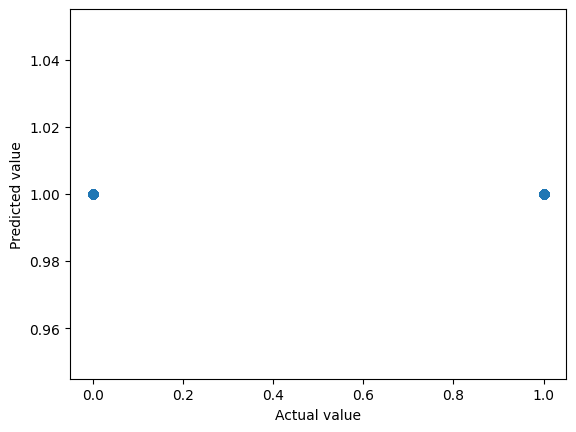

In [80]:
plt.scatter(y_test,prediction_svc)
plt.xlabel('Actual value')
plt.ylabel('Predicted value')
plt.show()

## Decision Tree